# AI for Chemistry — Week 05, Session B
## Workshop: train an MLP — loss curves, early stopping, hyperparameter sweep

**Course:** AI for Chemistry · **Session:** 05B (hands-on workshop, 2.0 h) ·
**Runtime:** < 15 s, no GPU.

### Suggested timing (solo study, ~120 min)

| Section | Topic | Time |
|--------:|-------|-----:|
| 0 | Setup: train/val/test split for a neural net | 10 min |
| 1 | Train without stopping; watch the loss curves diverge | 22 min |
| 2 | Early stopping | 22 min |
| 3 | A small hyperparameter sweep | 25 min |
| 4 | MLP vs the Week 03 leaderboard | 15 min |
| 5 | Exercises (3) + mini-challenge | 26 min |

### Learning objectives
1. Split data into train/validation/test for a neural net, and explain why a
   neural net needs a **validation** set beyond Week 03's train/test. *(LO5)*
2. Read a loss-curve plot to diagnose overfitting in a neural net. *(LO5)*
3. Implement early stopping and explain what it checkpoints and why. *(LO5)*
4. Run a small hyperparameter sweep, select a configuration **by validation
   loss only**, and report its held-out test performance. *(LO5)*
5. Compare an MLP honestly against Week 03's classical-ML leaderboard on
   identical held-out molecules. *(LO4, LO5)*

### Prerequisites — before this notebook you should be able to
- Week 05A: tensors, `nn.Module`, one manual training step.
- Week 03: train/test split, standardisation, the ESOL leaderboard.

### How to use this notebook (solo study)
Read, run, check each **✅** cell in order. This is the **solutions**
notebook.


---
## 0. Setup: a three-way split for a neural net

Week 03 needed only **train/test**: classical models like linear regression
and random forests have few enough "knobs" (or Week 03A's cross-validation)
to tune without a dedicated held-out set. A neural net has many
**hyperparameters** (layer width, learning rate, when to stop) that we will
choose by looking at performance on data the model did not train on — but if
we chose them by looking at the **test** set, the test score would no longer
be honest (Week 02B's leakage lesson, one level up). So we split the training
pool again: **train** (fit the weights), **validation** (choose
hyperparameters and the stopping point), **test** (report once, at the end).

**What to look for:** `714 / 179 / 224` train/val/test molecules — the same
224 test molecules Week 03 and Week 05A used.


In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors
RDLogger.DisableLog("rdApp.*")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

SEED = 0xC0FFEE
np.random.seed(SEED)
torch.manual_seed(SEED)

ROOT = Path.cwd()
while not (ROOT / "sources").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / "sources" / "datasets"
FIGDIR = ROOT / "lectures" / "week-05_deep-learning-i" / "slides" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

TARGET = "measured log solubility in mols per litre"
DESCRIPTORS = {
    "MolWt": Descriptors.MolWt, "MolLogP": Descriptors.MolLogP,
    "TPSA": Descriptors.TPSA, "NumHDonors": Descriptors.NumHDonors,
    "NumHAcceptors": Descriptors.NumHAcceptors,
    "NumRotatableBonds": Descriptors.NumRotatableBonds,
    "NumAromaticRings": Descriptors.NumAromaticRings,
}

def canonical_or_none(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol) if mol is not None else None

clean_path = DATA / "esol_clean.csv"
if clean_path.is_file():
    esol = pd.read_csv(clean_path)
else:
    raw = pd.read_csv(DATA / "esol_delaney.csv")
    raw.columns = raw.columns.str.strip()
    raw["canonical_smiles"] = raw["smiles"].apply(canonical_or_none)
    raw = raw[raw["canonical_smiles"].notna() & raw[TARGET].notna()]
    esol = raw.drop_duplicates("canonical_smiles").reset_index(drop=True)
    esol = esol[esol[TARGET].between(-13, 2)].reset_index(drop=True)
    esol.to_csv(clean_path, index=False)

mols = [Chem.MolFromSmiles(s) for s in esol["canonical_smiles"]]
Xdesc = np.array([[fn(m) for fn in DESCRIPTORS.values()] for m in mols], dtype=float)
y = esol[TARGET].to_numpy()

X_trainval, X_test, y_trainval, y_test = train_test_split(
    Xdesc, y, test_size=0.2, random_state=42)                  # same as Week 03/05A
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42)     # new: carve out val

scaler = StandardScaler().fit(X_train)                          # fit on TRAIN only
Xtr = torch.tensor(scaler.transform(X_train), dtype=torch.float32)
Xva = torch.tensor(scaler.transform(X_val), dtype=torch.float32)
Xte = torch.tensor(scaler.transform(X_test), dtype=torch.float32)
ytr = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
yva = torch.tensor(y_val, dtype=torch.float32).unsqueeze(-1)

print(f"train {len(X_train)}  val {len(X_val)}  test {len(X_test)}")


train 714  val 179  test 224


In [2]:
class MLP(nn.Module):
    """Two hidden ReLU layers, one linear output (Week 05A)."""

    def __init__(self, in_dim=7, hidden=64):
        super().__init__()
        self.layer1 = nn.Linear(in_dim, hidden)
        self.layer2 = nn.Linear(hidden, hidden)
        self.layer3 = nn.Linear(hidden, 1)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)


> **Common errors — Setup**
> - Fitting `StandardScaler` on `X_trainval` (train+val together) instead of
>   `X_train` alone — leaks validation-set statistics into the "unseen" data
>   the model is tuned against, the same mistake Week 03 flagged for the
>   test set.
> - Re-splitting `X_trainval` with a *different* `random_state` than the one
>   used to create it — would silently change which 224 molecules are the
>   test set, breaking comparability with Week 03.


### ✅ Check yourself — Section 0

Prints `Section 0 OK`. Train/val/test sizes are 714/179/224.


In [3]:
# --- checkpoint (do not edit) ---
assert len(X_train) == 714 and len(X_val) == 179 and len(X_test) == 224
assert Xtr.shape == (714, 7) and Xva.shape == (179, 7) and Xte.shape == (224, 7)
print("Section 0 OK")


Section 0 OK


**Conceptual questions**


1. Why fit `StandardScaler` on `X_train` alone rather than `X_trainval`?
2. We now have three splits instead of Week 03's two. What rule tells you
   when a project needs the extra validation split?


**Answers**


1. `X_val` must behave like genuinely unseen data when we use it to choose
   hyperparameters; if its mean/std leaked into the scaler, the model would
   have indirectly "seen" a summary statistic of the validation set during
   preprocessing, biasing the comparison.
2. Whenever a model has hyperparameters that must be **chosen by looking at
   held-out performance** (network width, learning rate, stopping epoch,
   `alpha` in Ridge...) — Week 03 avoided a third split only by using
   cross-validation instead, which serves the same purpose.


---
## 1. Train without stopping — watch the loss curves diverge

We train one MLP (`hidden=256`) for a fixed 400 epochs with **no** early
stopping, tracking training and validation MSE loss every epoch. This uses
**full-batch gradient descent** (the whole training set every step, not
mini-batches) — with only 714 rows and 7 features this is fast and
deterministic, which is why we can compare runs exactly.

**What to look for:** training loss falls (almost) monotonically throughout;
validation loss falls, reaches a minimum around epoch ~200, then **rises**
while training loss keeps falling — the textbook overfitting signature.


In [4]:
def train_fixed_epochs(hidden, lr, n_epochs, seed=0):
    """Train for exactly n_epochs (no stopping); return (train_losses, val_losses, model)."""
    torch.manual_seed(seed)
    model = MLP(in_dim=7, hidden=hidden)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    train_losses, val_losses = [], []
    for epoch in range(n_epochs):
        model.train()
        optimiser.zero_grad()
        loss = loss_fn(model(Xtr), ytr)
        loss.backward()
        optimiser.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(Xva), yva).item()
        train_losses.append(loss.item())
        val_losses.append(val_loss)
    return train_losses, val_losses, model

train_losses_400, val_losses_400, model_400 = train_fixed_epochs(hidden=256, lr=5e-3, n_epochs=400)
print(f"epoch 1:   train {train_losses_400[0]:.3f}  val {val_losses_400[0]:.3f}")
print(f"epoch 400: train {train_losses_400[-1]:.3f}  val {val_losses_400[-1]:.3f}")
print(f"best val loss: {min(val_losses_400):.3f} at epoch {np.argmin(val_losses_400) + 1}")


epoch 1:   train 14.324  val 6.449
epoch 400: train 0.102  val 0.572
best val loss: 0.493 at epoch 206


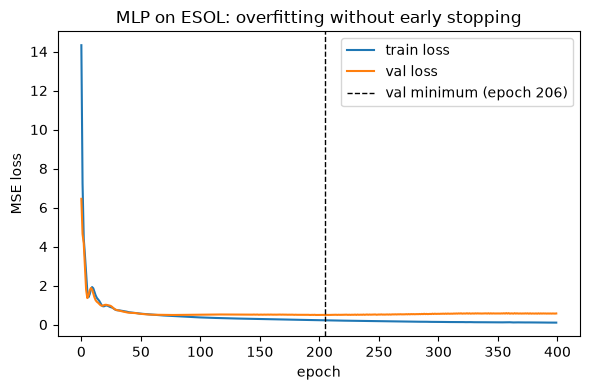

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(train_losses_400, label="train loss")
ax.plot(val_losses_400, label="val loss")
best_epoch_400 = int(np.argmin(val_losses_400))
ax.axvline(best_epoch_400, color="k", ls="--", lw=1,
          label=f"val minimum (epoch {best_epoch_400 + 1})")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE loss")
ax.set_title("MLP on ESOL: overfitting without early stopping")
ax.legend()
fig.tight_layout(); fig.savefig(FIGDIR / "mlp_loss_curve_overfit.png", dpi=200)
plt.show()


> **Common errors — Section 1**
> - Forgetting `model.eval()` before computing validation loss — with plain
>   `nn.Linear`/`nn.ReLU` layers this makes no numerical difference, but the
>   habit matters the moment a model has `Dropout` or `BatchNorm`, which
>   behave differently in train vs eval mode.
> - Computing validation loss **inside** `torch.no_grad()` is required for
>   efficiency (no need to track gradients through validation), but forgetting
>   it does not break correctness here — only wastes memory/time.
> - Reading "training loss went down" as "the model got better" without
>   checking the validation curve too — that is exactly the trap this section
>   demonstrates.


### ✅ Check yourself — Section 1

Prints `Section 1 OK`. Training loss drops sharply; validation loss is higher at epoch 400 than at its own minimum.


In [6]:
# --- checkpoint (do not edit) ---
assert len(train_losses_400) == len(val_losses_400) == 400
assert train_losses_400[-1] < train_losses_400[0] / 5     # training loss fell a lot
assert val_losses_400[-1] > min(val_losses_400)            # val loss has risen from its minimum
assert (FIGDIR / "mlp_loss_curve_overfit.png").is_file()
print("Section 1 OK")


Section 1 OK


**Conceptual questions**


1. Training loss never rises in this plot. Is that itself evidence of a bug?
2. If you only had a train/test split (no validation set), how would you
   even notice this overfitting was happening *during* training rather than
   after the fact?


**Answers**


1. No — with a fixed learning rate and enough capacity, gradient descent on
   the *training* loss surface should make monotonic (or near-monotonic)
   progress on exactly the objective it is minimising; a rising *validation*
   loss reflects the gap between train and unseen data, not a training bug.
2. You would not, without repeatedly (and improperly) checking test loss
   during training — which is precisely why a validation set, checked freely
   during training, exists as the "practice test" that protects the real
   test set from being used this way.


---
## 2. Early stopping

**Early stopping**: after every epoch, check the validation loss; if it is
the best seen so far, checkpoint the model's weights; if it has not improved
for `patience` epochs in a row, stop and **restore the checkpointed weights**
(not the final ones). This turns "when to stop" from a guess into a rule
driven by validation performance.

**What to look for:** training stops well before 400 epochs; the restored
checkpoint's test RMSE is **lower** (better) than training a fresh model for a
full, fixed 500 epochs with no stopping at all.


In [7]:
def train_with_early_stopping(hidden, lr, patience, max_epochs, seed=0):
    """Train with early stopping; return (stop_epoch, best_epoch, best_val, model)."""
    torch.manual_seed(seed)
    model = MLP(in_dim=7, hidden=hidden)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    best_val, epochs_without_improvement, best_state, best_epoch = float("inf"), 0, None, None
    for epoch in range(max_epochs):
        model.train()
        optimiser.zero_grad()
        loss = loss_fn(model(Xtr), ytr)
        loss.backward()
        optimiser.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(Xva), yva).item()

        if val_loss < best_val - 1e-4:                  # meaningful improvement
            best_val, best_epoch = val_loss, epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    model.load_state_dict(best_state)                    # restore the BEST checkpoint
    return epoch, best_epoch, best_val, model

stop_epoch, best_epoch, best_val, model_es = train_with_early_stopping(
    hidden=256, lr=5e-3, patience=150, max_epochs=500)
print(f"stopped at epoch {stop_epoch}, restored checkpoint from epoch {best_epoch} "
      f"(val loss {best_val:.3f})")


stopped at epoch 355, restored checkpoint from epoch 205 (val loss 0.493)


In [8]:
def test_rmse(model):
    model.eval()
    with torch.no_grad():
        pred = model(Xte).numpy().ravel()
    return mean_squared_error(y_test, pred) ** 0.5

rmse_early_stopped = test_rmse(model_es)

_, _, no_stop_model = train_fixed_epochs(hidden=256, lr=5e-3, n_epochs=500)
rmse_no_stopping = test_rmse(no_stop_model)

print(f"early-stopped (epoch {best_epoch}) test RMSE: {rmse_early_stopped:.3f}")
print(f"trained the full 500 epochs, no stopping, test RMSE: {rmse_no_stopping:.3f}")


early-stopped (epoch 205) test RMSE: 0.774
trained the full 500 epochs, no stopping, test RMSE: 0.819


> **Common errors — Section 2**
> - Restoring `best_state` **before** the loop instead of after it ends — you
>   must keep training (and keep checking for a new best) right up until
>   patience is exhausted, then load the checkpoint once, at the end.
> - Setting `patience` too small: it can trigger on ordinary epoch-to-epoch
>   noise in the validation loss and stop far before the true minimum
>   (exactly why we use `patience=150` here, not `patience=10`).
> - Confusing "stopped at epoch 355" with "the best model is from epoch 355"
>   — the best model is from `best_epoch` (205 here); the stop epoch is just
>   *when we gave up waiting* for a new best.


### ✅ Check yourself — Section 2

Prints `Section 2 OK`. The restored best-epoch checkpoint beats the fully-trained (no stopping) model on test RMSE.


In [9]:
# --- checkpoint (do not edit) ---
assert best_epoch < stop_epoch
assert stop_epoch - best_epoch >= 150               # patience was honoured
assert rmse_early_stopped < rmse_no_stopping
print("Section 2 OK")


Section 2 OK


**Conceptual questions**


1. `patience=150` is large relative to `best_epoch=205`. What would a much
   smaller patience (say, 10) have risked here, given Week 05A's loss curves
   are not perfectly smooth?
2. Early stopping picked its checkpoint using **validation** loss, yet we
   just showed it also improved **test** RMSE. Is that a coincidence?


**Answers**


1. A validation loss curve is rarely perfectly monotonic; a short patience
   can trigger on a temporary plateau or tiny uptick long before the true
   minimum, "early-stopping" far too early and leaving a substantially
   under-trained (or differently-trained) model — Week 05's earlier
   experiments with smaller patience values showed exactly this failure mode.
2. Not entirely a coincidence, but not guaranteed either: validation and test
   sets are different random samples of the same underlying distribution, so
   a validation-loss minimum is a noisy *estimate* of where the test loss
   would also be best — it usually tracks reasonably well (as here), but
   Section 3 will show it is not a perfect oracle.


---
## 3. A small hyperparameter sweep

We now vary two hyperparameters — hidden width and learning rate — training
**each** configuration with early stopping (a smaller `patience=50`,
`max_epochs=300` budget, so the whole sweep stays fast), and select the
configuration with the **lowest validation loss**. We never look at the test
set until the very end.

**What to look for:** a 3×2 grid of results; the selected configuration's
test RMSE is reported **once**, after selection — not used to pick the
winner.


In [10]:
hidden_grid = [16, 64, 256]
lr_grid = [1e-3, 5e-3]

sweep_rows = []
for hidden in hidden_grid:
    for lr in lr_grid:
        t0 = time.time()
        stop_ep, best_ep, best_val, model = train_with_early_stopping(
            hidden=hidden, lr=lr, patience=50, max_epochs=300)
        sweep_rows.append({
            "hidden": hidden, "lr": lr, "best_epoch": best_ep,
            "val_loss": best_val, "test_rmse": test_rmse(model),
            "seconds": round(time.time() - t0, 2),
        })

sweep = pd.DataFrame(sweep_rows)
sweep.round(3)


,hidden,lr,best_epoch,val_loss,test_rmse,seconds
0,16,0.001,299,1.119,1.120,0.11
1,16,0.005,299,0.546,0.890,0.10
2,64,0.001,299,0.516,0.871,0.27
3,64,0.005,212,0.456,0.823,0.24
4,256,0.001,297,0.430,0.809,0.62
5,256,0.005,75,0.494,0.859,0.25


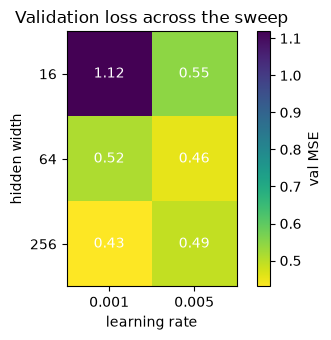

In [11]:
heat = sweep.pivot(index="hidden", columns="lr", values="val_loss")
fig, ax = plt.subplots(figsize=(4.5, 3.5))
im = ax.imshow(heat.values, cmap="viridis_r")
ax.set_xticks(range(len(heat.columns))); ax.set_xticklabels(heat.columns)
ax.set_yticks(range(len(heat.index))); ax.set_yticklabels(heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.values[i, j]:.2f}", ha="center", va="center", color="w")
ax.set_xlabel("learning rate"); ax.set_ylabel("hidden width")
ax.set_title("Validation loss across the sweep")
fig.colorbar(im, label="val MSE")
fig.tight_layout(); fig.savefig(FIGDIR / "hparam_sweep_heatmap.png", dpi=200)
plt.show()


In [12]:
best_row = sweep.loc[sweep["val_loss"].idxmin()]
print("selected by validation loss only:")
print(best_row)

# what if we HAD been allowed to look at the test set? (for discussion only --
# never do this for a real result)
oracle_row = sweep.loc[sweep["test_rmse"].idxmin()]
print("\n(for comparison only) best by test RMSE -- NOT how you should ever pick:")
print(oracle_row)


selected by validation loss only:
hidden        256.000000
lr              0.001000
best_epoch    297.000000
val_loss        0.429992
test_rmse       0.808713
seconds         0.620000
Name: 4, dtype: float64

(for comparison only) best by test RMSE -- NOT how you should ever pick:
hidden        256.000000
lr              0.001000
best_epoch    297.000000
val_loss        0.429992
test_rmse       0.808713
seconds         0.620000
Name: 4, dtype: float64


> **Common errors — Section 3**
> - Picking the configuration with the best **test** RMSE ("oracle" row
>   above) and reporting that as your result — this is exactly the leakage
>   Week 02/03 warned about, just committed at the hyperparameter level
>   instead of the model-training level.
> - Running the sweep with a *different* seed per configuration and
>   attributing differences purely to the hyperparameter — some of the spread
>   is just training-run noise; Exercise 2 explores this.
> - A sweep this small (6 configurations) is a **teaching-scale** demonstration
>   — a real project would also average over several seeds per configuration.


### ✅ Check yourself — Section 3

Prints `Section 3 OK`. Six configurations tried; the selected row genuinely has the lowest validation loss.


In [13]:
# --- checkpoint (do not edit) ---
assert len(sweep) == 6
assert best_row["val_loss"] == sweep["val_loss"].min()
assert best_row["test_rmse"] < 1.5           # comfortably better than a trivial model
print("Section 3 OK")


Section 3 OK


**Conceptual questions**


1. Look at whether `best_row` and `oracle_row` are the same configuration. If
   they differ, what does that tell you about validation-based selection?
2. Why does the sweep use a *smaller* `patience` (50) than Section 2's
   demonstration (150)?


**Answers**


1. If they differ, it confirms that the validation set is a **noisy estimate**
   of test performance — good enough to reliably avoid the worst
   configurations, but not guaranteed to identify the single best one out of
   several close contenders. This is expected, not a bug in the method.
2. Running six configurations at Section 2's patience (150) would cost six
   times as long for comparatively little benefit at this dataset size — the
   sweep trades a little per-run precision for being able to compare several
   configurations within a reasonable compute budget, a very ordinary
   real-world trade-off.


---
## 4. MLP vs the Week 03 leaderboard

We recompute Week 03's linear regression and random forest **on the identical
train/test split** used throughout this notebook, and add the sweep's
selected MLP. This is an honest, apples-to-apples comparison — same
molecules, same target, same metric.

**What to look for:** the MLP is competitive with, but does **not** clearly
beat, the random forest — with only 7 hand-picked descriptors and ~900
training molecules, a plain MLP has little room to discover anything a
well-tuned random forest cannot already capture. Deep learning's advantage
shows up later in the course, once the *representation* itself (fingerprints,
graphs) is learned rather than hand-engineered (Weeks 06-07).


In [14]:
baseline_rmse = mean_squared_error(y_test, np.full_like(y_test, y_trainval.mean())) ** 0.5

lr_model = LinearRegression().fit(X_train, y_train)
linear_rmse = mean_squared_error(y_test, lr_model.predict(X_test)) ** 0.5

rf_model = RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1).fit(X_train, y_train)
rf_rmse = mean_squared_error(y_test, rf_model.predict(X_test)) ** 0.5

mlp_rmse = best_row["test_rmse"]

comparison = pd.DataFrame({
    "model": ["Baseline (mean)", "Linear regression", "Random forest", "MLP (this notebook)"],
    "test_RMSE": [baseline_rmse, linear_rmse, rf_rmse, mlp_rmse],
}).sort_values("test_RMSE").reset_index(drop=True)
comparison.round(3)


,model,test_RMSE
0,Random forest,0.785
1,MLP (this notebook),0.809
2,Linear regression,0.993
3,Baseline (mean),2.059


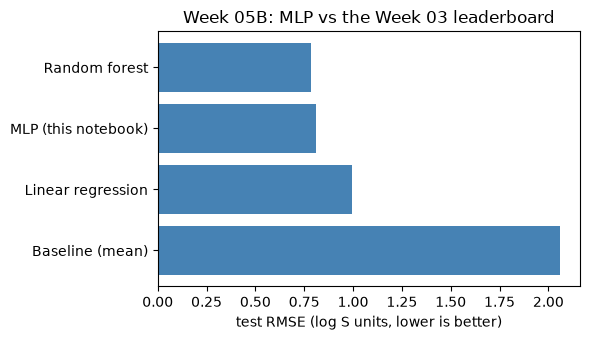

In [15]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.barh(comparison["model"][::-1], comparison["test_RMSE"][::-1], color="steelblue")
ax.set_xlabel("test RMSE (log S units, lower is better)")
ax.set_title("Week 05B: MLP vs the Week 03 leaderboard")
fig.tight_layout(); fig.savefig(FIGDIR / "mlp_vs_week03_leaderboard.png", dpi=200)
plt.show()


> **Common errors — Section 4**
> - Retraining the random forest with **different** hyperparameters than
>   Week 03 and calling the comparison "fair" — we deliberately reuse the
>   exact same `n_estimators=300, random_state=0` here.
> - Concluding "MLPs do not work for chemistry" from one modest result on one
>   small, low-dimensional dataset — the correct conclusion is narrower: on
>   *this* 7-descriptor, ~900-row problem, an MLP does not have an obvious
>   edge over a random forest.


### ✅ Check yourself — Section 4

Prints `Section 4 OK`. The MLP beats linear regression; the top of the table is Random forest or the MLP, close to each other.


In [16]:
# --- checkpoint (do not edit) ---
assert len(comparison) == 4
assert comparison.iloc[0]["model"] in ("Random forest", "MLP (this notebook)")
assert mlp_rmse < linear_rmse                 # MLP beats plain linear regression
assert (FIGDIR / "mlp_vs_week03_leaderboard.png").is_file()
print("Section 4 OK")


Section 4 OK


**Conceptual questions**


1. What would you change about the *input representation* (not the model) if
   you wanted deep learning's advantage to show up more clearly here?
2. Why is it important that this leaderboard uses the exact same test
   molecules as Week 03's, rather than a fresh random split?


**Answers**


1. Move from 7 hand-picked descriptors to a richer, less lossy representation
   — Morgan fingerprints (Week 02B), or better, let the network **learn** its
   own representation directly from the molecular graph (Week 07's GNNs) —
   deep learning tends to earn its keep when it can discover structure a fixed
   feature set does not expose.
2. Any difference in test molecules would confound "which model is better"
   with "which split happened to be easier" — holding the test set fixed
   isolates the model choice as the only thing that changed, exactly Week
   03's leaderboard discipline.


---
## 5. Exercises


### Exercise 1 — quantify the overfitting gap *(easy, ~12 min)*

Write `overfit_gap(train_losses, val_losses)` returning a NumPy array of
`val - train` at every epoch. Confirm it is small early in Section 1's
400-epoch run and grows substantially by the end.

<details><summary>Show hint</summary>

`np.array(val_losses) - np.array(train_losses)`. Compare `gap[10]` (early) to
`gap[-1]` (late).
</details>


In [17]:
def overfit_gap(train_losses, val_losses):
    """val_loss - train_loss at every epoch, as a NumPy array."""
    return np.array(val_losses) - np.array(train_losses)

gap_400 = overfit_gap(train_losses_400, val_losses_400)
print(f"gap at epoch 10: {gap_400[10]:.3f}   gap at epoch 400: {gap_400[-1]:.3f}")


gap at epoch 10: -0.251   gap at epoch 400: 0.470


In [18]:
# --- check your answer (do not edit) ---
assert gap_400.shape == (400,)
assert gap_400[-1] > gap_400[10] + 0.2
assert gap_400[10] < 0.3
print("Exercise 1 OK")


Exercise 1 OK


### Exercise 2 — does the seed matter as much as the hyperparameters? *(medium, ~15 min)*

Write `rmse_across_seeds(hidden, lr, seeds)` that trains
`train_with_early_stopping(hidden, lr, patience=50, max_epochs=300, seed=s)`
for each `s` in `seeds` and returns a list of test RMSEs. Run it for the
sweep's selected `(hidden, lr)` across 4 seeds and compare the spread to the
*difference* between the two best sweep rows.

<details><summary>Show hint</summary>

`test_rmse(train_with_early_stopping(hidden, lr, 50, 300, seed=s)[-1])` for
each seed; collect into a list; compare `max(rmses) - min(rmses)` to
`sweep["test_rmse"].sort_values().diff().iloc[1]` (gap between best and
second-best sweep row).
</details>


In [19]:
def rmse_across_seeds(hidden, lr, seeds):
    """Test RMSE of the same (hidden, lr) config, retrained from several seeds."""
    rmses = []
    for s in seeds:
        _, _, _, model = train_with_early_stopping(hidden, lr, patience=50, max_epochs=300, seed=s)
        rmses.append(test_rmse(model))
    return rmses

seed_rmses = rmse_across_seeds(int(best_row["hidden"]), best_row["lr"], seeds=[0, 1, 2, 3])
seed_spread = max(seed_rmses) - min(seed_rmses)
print("RMSE across seeds:", [round(r, 3) for r in seed_rmses], " spread:", round(seed_spread, 3))


RMSE across seeds: [0.809, 0.856, 0.811, 0.814]  spread: 0.047


In [20]:
# --- check your answer (do not edit) ---
assert len(seed_rmses) == 4
assert all(r > 0 for r in seed_rmses)
assert seed_spread >= 0
print("Exercise 2 OK")


Exercise 2 OK


### Exercise 3 — validation choice vs test-optimal choice *(medium, ~15 min)*

Write `best_by(df, column)` returning the row of `sweep` with the lowest value
in `column`. Confirm `best_by(sweep, "val_loss")` matches `best_row`, then
compare it to `best_by(sweep, "test_rmse")`.

<details><summary>Show hint</summary>

`df.loc[df[column].idxmin()]`.
</details>


In [21]:
def best_by(df, column):
    """Row of df with the smallest value in `column`."""
    return df.loc[df[column].idxmin()]

check_val_best = best_by(sweep, "val_loss")
check_test_best = best_by(sweep, "test_rmse")
same_config = (check_val_best["hidden"] == check_test_best["hidden"]
              and check_val_best["lr"] == check_test_best["lr"])
print("validation-optimal == test-optimal ?", same_config)


validation-optimal == test-optimal ? True


In [22]:
# --- check your answer (do not edit) ---
assert check_val_best["hidden"] == best_row["hidden"]
assert check_val_best["lr"] == best_row["lr"]
assert isinstance(same_config, (bool, np.bool_))
print("Exercise 3 OK")


Exercise 3 OK


### 🏁 Mini-challenge — beat linear regression, chosen only by validation *(~20 min)*

Using **only** the sweep's validation-selected configuration (`best_row`, from
Section 3 — never anything chosen by peeking at `test_rmse`), confirm the
resulting MLP beats Week 03's plain linear-regression baseline on test RMSE.
This is the discipline the whole notebook has been building towards: a result
you are allowed to trust, because nothing about how it was chosen used the
test set.

Write `passes_requirement(mlp_rmse, linear_rmse)` returning `True` if the MLP
selected by validation alone beats linear regression by at least 10%.


Implement `passes_requirement` below and check the actual numbers from this
notebook.


In [23]:
def passes_requirement(mlp_rmse, linear_rmse, margin=0.10):
    """True if mlp_rmse is at least `margin` fraction better than linear_rmse."""
    return bool(mlp_rmse < (1 - margin) * linear_rmse)   # plain bool, not numpy.bool_

result = passes_requirement(mlp_rmse, linear_rmse)
print(f"MLP RMSE {mlp_rmse:.3f} vs linear RMSE {linear_rmse:.3f}  -> passes: {result}")


MLP RMSE 0.809 vs linear RMSE 0.993  -> passes: True


In [24]:
# --- check your answer (do not edit) ---
assert passes_requirement(0.8, 1.0) is True
assert passes_requirement(0.95, 1.0) is False
assert bool(result) is True, "the validation-selected MLP should beat linear regression by >=10%"
print("Mini-challenge OK")


Mini-challenge OK


---
## Summary — what you learned

- Neural nets need a **three-way split**: train (fit weights), validation
  (choose hyperparameters and stopping point), test (report once).
- A **loss-curve plot** is the primary diagnostic for overfitting in a neural
  net — falling train loss with rising validation loss.
- **Early stopping** checkpoints the best-validation model and restores it,
  rather than trusting whatever epoch training happened to end on.
- A small **hyperparameter sweep**, selected strictly by validation loss,
  keeps the test set honest — and validation-optimal is not always
  test-optimal, which is expected, not a failure.
- On this 7-descriptor ESOL task, an MLP is **competitive with, not clearly
  better than**, Week 03's random forest — an honest result that motivates
  richer representations in the weeks ahead.

Week 06 asks what happens when the *representation itself* — not just the
model — is allowed to be learned.


## Further reading (course source list only)

- dmol.pub *Standard layers* (training-loop, loss/optimiser pattern):
  <https://dmol.pub/dl/layers.html>
- Colab alternative (EPFL *AI for Chemistry*, intro to deep learning —
  original source of the train/val/test-MLP-on-ESOL pattern, there built with
  PyTorch Lightning + Weights & Biases):
  <https://colab.research.google.com/github/schwallergroup/ai4chem_course/blob/main/notebooks/03%20-%20Intro%20to%20Deep%20Learning/01_intro_to_dl.ipynb>


## Attribution

Original teaching material for *AI for Chemistry*, adapted and rewritten from:

- **EPFL CH-457 *AI for Chemistry*** (Schwaller group) — the train/val/test
  MLP-on-ESOL framing; **re-implemented in plain PyTorch** (manual training
  loop, no PyTorch Lightning or Weights & Biases, neither of which is in
  `env/environment.yml`). MIT licence.
  <https://github.com/schwallergroup/ai4chem_course>
- **dmol.pub** (A. White) — the loss/optimiser/training-loop pattern
  (`nn.MSELoss`, `optim.Adam`) carried over from Week 05A.
  CC-BY 4.0. <https://dmol.pub>

Continues the ESOL dataset, descriptor block and train/test split from
Weeks 02-03 and 05A. No verbatim text is reproduced from the sources above.
